# 01.GoEmotions Dataset EDA

This notebook explores the raw GoEmotions CSV files before preprocessing.

- Load the three GoEmotions CSV files.
- Check dataset shape and columns.
- Identify emotion label columns.
- Check unclear examples.
- Visualize original emotion distribution.
- Preview how the 28 GoEmotions labels will be grouped into 7 project emotions.

In [1]:
# Import required libraries
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 1. Set paths

In [2]:
# Project root assumes this notebook is inside: project/notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Raw GoEmotions files
RAW_FILES = [
    RAW_DATA_DIR / "goemotions_1.csv",
    RAW_DATA_DIR / "goemotions_2.csv",
    RAW_DATA_DIR / "goemotions_3.csv",
]

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)

# Check that all files exist
for file_path in RAW_FILES:
    print(file_path.name, "exists:", file_path.exists())

Project root: c:\Users\Taruni\Desktop\PetChat-2.0\emotion_classifier
Raw data directory: c:\Users\Taruni\Desktop\PetChat-2.0\emotion_classifier\data\raw
goemotions_1.csv exists: True
goemotions_2.csv exists: True
goemotions_3.csv exists: True


## 2. Load the dataset

In [3]:
# Load and combine all three GoEmotions CSV files
df_list = []

for file_path in RAW_FILES:
    temp_df = pd.read_csv(file_path)
    df_list.append(temp_df)
    print(f"{file_path.name}: {temp_df.shape}")

df = pd.concat(df_list, ignore_index=True)

print("\nCombined dataset shape:", df.shape)
df.head()

goemotions_1.csv: (70000, 37)
goemotions_2.csv: (70000, 37)
goemotions_3.csv: (71225, 37)

Combined dataset shape: (211225, 37)


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


## 3. Check columns and basic information

In [4]:
# Show all columns
print("Number of columns:", len(df.columns))
print(df.columns.tolist())

Number of columns: 37
['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [5]:
# Basic dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 37 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   text                  211225 non-null  str    
 1   id                    211225 non-null  str    
 2   author                211225 non-null  str    
 3   subreddit             211225 non-null  str    
 4   link_id               211225 non-null  str    
 5   parent_id             211225 non-null  str    
 6   created_utc           211225 non-null  float64
 7   rater_id              211225 non-null  int64  
 8   example_very_unclear  211225 non-null  bool   
 9   admiration            211225 non-null  int64  
 10  amusement             211225 non-null  int64  
 11  anger                 211225 non-null  int64  
 12  annoyance             211225 non-null  int64  
 13  approval              211225 non-null  int64  
 14  caring                211225 non-null  int64  
 15  confusion  

## 4. Identify emotion label columns

In [6]:
# Non-emotion metadata columns in GoEmotions
metadata_cols = [
    "text", "id", "author", "subreddit", "link_id", "parent_id",
    "created_utc", "rater_id", "example_very_unclear"
]

# Emotion columns are all columns except metadata columns
emotion_cols = [col for col in df.columns if col not in metadata_cols]

print("Number of emotion label columns:", len(emotion_cols))
print(emotion_cols)

Number of emotion label columns: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


## 5. Check unclear examples

In [7]:
# The dataset contains examples marked as unclear.
# These rows are usually not good for training.
unclear_count = df["example_very_unclear"].sum()
clear_count = len(df) - unclear_count

print("Clear examples:", clear_count)
print("Unclear examples:", unclear_count)
print("Unclear percentage:", round((unclear_count / len(df)) * 100, 2), "%")

Clear examples: 207814
Unclear examples: 3411
Unclear percentage: 1.61 %


## 6. Original GoEmotions class distribution

,count
neutral,55298
approval,17620
admiration,17131
annoyance,13618
gratitude,11625
disapproval,11424
curiosity,9692
amusement,9245
realization,8785
optimism,8715


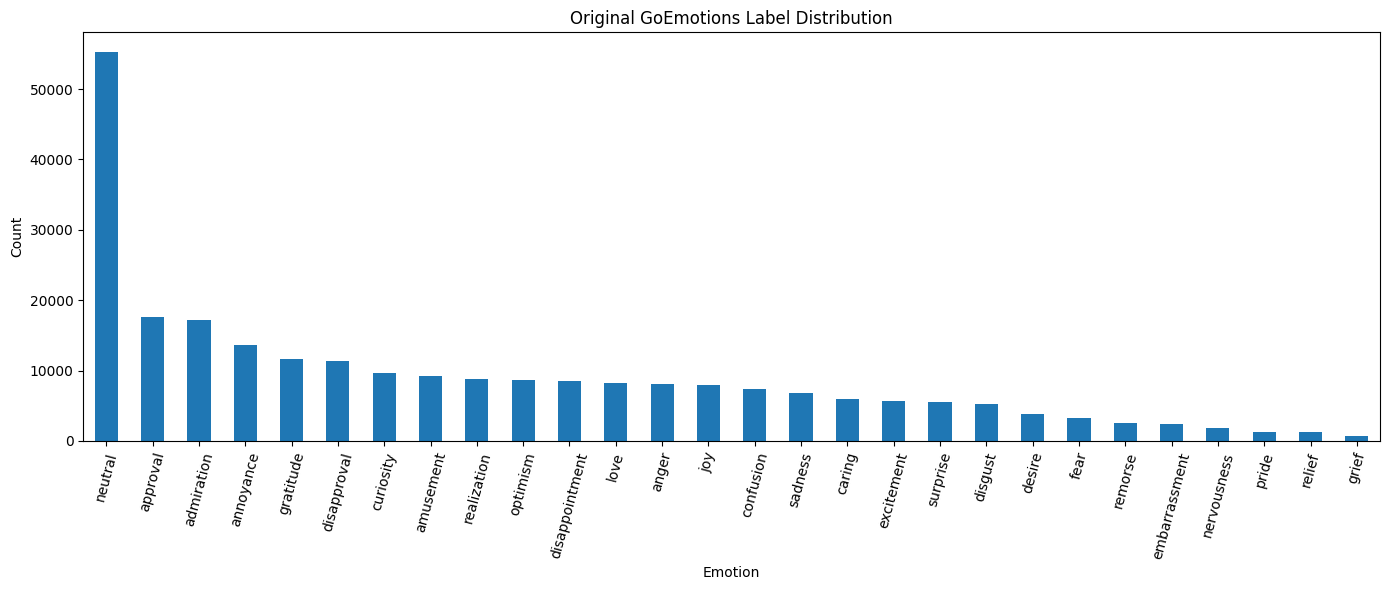

In [8]:
# Count how many times each original emotion appears
original_counts = df[emotion_cols].sum().sort_values(ascending=False)

display(original_counts.to_frame(name="count"))

plt.figure(figsize=(14, 6))
original_counts.plot(kind="bar")
plt.title("Original GoEmotions Label Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## 7. Check multi-label samples

,row_count
num_active_labels,
0,3411
1,171820
2,31187
3,4218
4,399
5,106
6,53
7,20
8,6


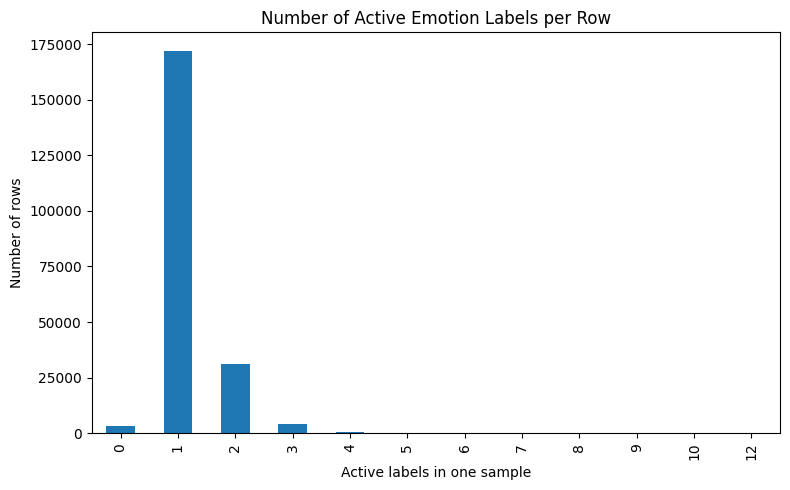

In [9]:
# GoEmotions is multi-label, meaning one row can have more than one active emotion.
df["num_active_labels"] = df[emotion_cols].sum(axis=1)

label_count_distribution = df["num_active_labels"].value_counts().sort_index()
display(label_count_distribution.to_frame(name="row_count"))

plt.figure(figsize=(8, 5))
label_count_distribution.plot(kind="bar")
plt.title("Number of Active Emotion Labels per Row")
plt.xlabel("Active labels in one sample")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()

## 8. Map original emotions into 7 project emotions

In [10]:
# Fixed 7-emotion label order used throughout the whole project.
# Do NOT change this order after preprocessing, because it controls label_id values.
UI_LABEL_NAMES = ["happy", "calm", "sad", "angry", "anxious", "stressed", "confused"]

# Mapping from GoEmotions labels into 7 UI emotions.
# GoEmotions has 27 emotions + neutral = 28 label columns.
UI_MAPPING = {
    "happy": [
        "admiration", "amusement", "approval", "desire", "excitement",
        "gratitude", "joy", "love", "optimism", "pride"
    ],
    "calm": [
        "neutral", "relief", "caring"
    ],
    "sad": [
        "disappointment", "embarrassment", "grief", "remorse", "sadness"
    ],
    "angry": [
        "anger", "annoyance", "disapproval", "disgust"
    ],
    "anxious": [
        "fear"
    ],
    "stressed": [
        "nervousness"
    ],
    "confused": [
        "confusion", "curiosity", "realization", "surprise"
    ],
}

# Reverse mapping: original emotion -> UI emotion.
GO_TO_UI = {}
for ui_label, original_labels in UI_MAPPING.items():
    for original_label in original_labels:
        GO_TO_UI[original_label] = ui_label

In [11]:
# Preview the mapping in table form
mapping_rows = []
for ui_label, original_labels in UI_MAPPING.items():
    mapping_rows.append({
        "ui_emotion": ui_label,
        "mapped_goemotions_labels": ", ".join(original_labels),
        "number_of_original_labels": len(original_labels)
    })

mapping_df = pd.DataFrame(mapping_rows)
display(mapping_df)

,ui_emotion,mapped_goemotions_labels,number_of_original_labels
0,happy,"admiration, amusement, approval, desire, excit...",10
1,calm,"neutral, relief, caring",3
2,sad,"disappointment, embarrassment, grief, remorse,...",5
3,angry,"anger, annoyance, disapproval, disgust",4
4,anxious,fear,1
5,stressed,nervousness,1
6,confused,"confusion, curiosity, realization, surprise",4
